# LangGraph 기초

### 필요한 패키지 설치
`pip install langgraph`

In [1]:
import operator
from typing import Annotated, TypedDict

from dotenv import load_dotenv
from IPython.display import Image, display
from langchain_chroma import Chroma
from langchain_core.messages import AIMessage, HumanMessage
from langchain_google_genai import ChatGoogleGenerativeAI, GoogleGenerativeAIEmbeddings
from langgraph.graph import END, START, StateGraph
from langgraph.graph.message import add_messages

load_dotenv()

True

### 직선형 Chain을 넘어서는 요구사항

LCEL Chain은 입력을 정해진 순서로 처리하는 **직선형 파이프라인**에 잘 맞는다.

```
입력 → 프롬프트 → 모델 → 출력 파서 → 결과
```

하지만 실제 서비스에는 실행 도중 다음 행동을 결정해야 하는 상황이 자주 등장한다.

- 고객 문의를 처리할 때 환불 요청은 환불 담당 흐름으로, 제품 문의는 상담 흐름으로 보내야 한다.
- 문서를 검색했는데 답변에 필요한 내용이 부족하면 질문을 고쳐 다시 검색해야 한다. 검색이 계속 실패하면 정해진 횟수에서 중단해야 한다.
- 결제나 메일 발송처럼 영향이 큰 작업은 실행 직전에 멈추고 사용자의 승인을 기다려야 한다.
- 실행 중 오류가 발생하면 처음부터 다시 시작하지 않고 저장된 상태를 바탕으로 이어서 처리해야 한다.
- Agent가 검색, 계산, 데이터 조회 중 어떤 Tool이 필요한지 판단하고 결과가 충분할 때까지 사용해야 한다.

이 요구사항들도 일반 Python 코드와 LangChain을 조합하면 구현할 수 있다. 문제는 분기, 반복, 상태 저장, 중단과 재개가 늘어날수록 **제어 로직이 Chain 밖의 조건문과 반복문으로 흩어진다**는 점이다. 실행 흐름을 이해하고 추적하거나, 중간 상태에서 다시 시작하는 일도 점점 어려워진다.

| 필요한 제어 흐름 | 자연어 사례 | LangGraph에서 사용할 개념 |
|---|---|---|
| 조건 분기 | 문의 유형에 따라 서로 다른 처리 과정 선택 | 조건부 Edge |
| 반복과 종료 조건 | 검색 결과가 부족하면 질문을 바꾸어 재검색 | 순환 구조, 조건부 Edge |
| 중간 결과 누적 | 조사 결과와 남은 작업을 단계마다 공유 | State, Reducer |
| 사람의 개입 | 승인받을 때까지 실행을 멈추고 이후 재개 | Interrupt, Checkpoint |
| 병렬 처리와 취합 | 여러 분석을 동시에 수행한 뒤 결과 통합 | Send, Reducer |
| 장애 후 복구 | 저장된 중간 상태부터 작업 재개 | Checkpoint |
| 동적인 행동 선택 | LLM이 다음 Tool과 실행 횟수를 결정 | Agent, ToolNode |

> LangGraph는 LangChain으로 할 수 없던 일을 가능하게 만드는 도구라기보다, 복잡한 제어 흐름과 상태 변화를 **명시적인 그래프**로 관리하게 해주는 프레임워크다.

### 대표 사례: 검색 결과가 부족하면 재검색

앞의 여러 상황을 모두 코드로 구현하지 않고, 그중 반복과 종료 조건이 필요한 사례 하나만 살펴보자.

"검색 결과가 부족하면 질문을 바꾸어 다시 검색한다"는 요구사항을 일반 Python 코드와 Chain으로 구현하면 다음과 같이 제어 로직이 Chain 밖으로 나오게 된다.

In [2]:
EMBEDDING_MODEL_NAME = "gemini-embedding-2"
MODEL_NAME = "gemini-3.6-flash"

embeddings = GoogleGenerativeAIEmbeddings(model=EMBEDDING_MODEL_NAME)
llm = ChatGoogleGenerativeAI(model=MODEL_NAME)

vectorstore = Chroma(
    embedding_function=embeddings,
    collection_name="spri_ai_brief",
    persist_directory="./chroma_db",
)
retriever = vectorstore.as_retriever(search_kwargs={"k": 3})


def format_docs(docs):
    return "\n\n".join(doc.page_content for doc in docs)

In [3]:
question = "AI 반도체 시장의 전망은?"
max_retries = 3

for attempt in range(max_retries):
    docs = retriever.invoke(question)
    context = format_docs(docs)

    check = llm.invoke([
        HumanMessage(
            content=f"질문: {question}\n\n검색 결과:\n{context}\n\n"
            "이 검색 결과가 질문에 답변하기에 충분한가? 'yes' 또는 'no'로만 답해."
        )
    ])

    print(f"[시도 {attempt + 1}] 질문: {question}")
    check_text = check.text
    print(f"  충분한가? {check_text}")

    if "yes" in check_text.lower():
        break

    rewrite = llm.invoke([
        HumanMessage(
            content=f"'{question}'이라는 질문으로 문서를 검색했지만 충분한 결과가 없었다. "
            "같은 의도이지만 다른 표현으로 질문을 다시 작성해줘. 질문만 출력해."
        )
    ])
    question = rewrite.text

print(f"\n→ 모델 호출은 Chain 안에 있지만, 반복과 종료 조건은 Python 루프가 제어한다.")
print("→ 요구사항이 늘어날수록 제어 흐름과 상태 관리가 Chain 밖으로 흩어진다.")

Direct use of automatic function calling (AFC) in Models.generate_content is not recommended. Instead, we recommend to use AFC in Chat.send_message. Similarly, direct use of AFC in Models.generate_content_stream is not recommended. Instead, we recommend to use AFC in Chat.send_message_stream.


[시도 1] 질문: AI 반도체 시장의 전망은?
  충분한가? no
[시도 2] 질문: 1. 인공지능(AI) 반도체 산업의 미래 성장성과 시장 규모 예측은?
2. 향후 AI 칩 시장의 주요 트렌드 및 동향은 어떻게 되나요?
3. 글로벌 AI 반도체 시장의 성장 가능성과 향후 전망
4. 차세대 AI 반도체 관련 산업 동향과 시장 예측에 대해 알려줘.
  충분한가? no
[시도 3] 질문: 1. 생성형 AI 확산에 따른 글로벌 AI 가속기(GPU, NPU) 시장 규모 및 연평균 성장률(CAGR) 전망은?
2. 빅테크 기업들의 AI 칩 자체 개발 동향과 차세대 지능형 반도체 기술 트렌드는 무엇인가요?
3. 초거대 AI용 반도체 산업의 미래 성장 가능성과 향후 5~10년간의 시장 예측 데이터
4. HBM, PIM 등 차세대 AI 반도체 관련 최신 기술 동향 및 글로벌 시장 전망을 알려주세요.
  충분한가? no

→ 모델 호출은 Chain 안에 있지만, 반복과 종료 조건은 Python 루프가 제어한다.
→ 요구사항이 늘어날수록 제어 흐름과 상태 관리가 Chain 밖으로 흩어진다.


## Workflow vs Agent

AI 애플리케이션의 제어 방식은 **스펙트럼** 위에 있다.

```
개발자가 흐름 결정                                    LLM이 흐름 결정
├──────────────────────────────────────────────────────────┤
Chain       Workflow        Agent           Autonomous Agent
(직선)       (분기+루프)     (LLM이 판단)            (완전 자율)
```

| 방식 | 제어 주체 | 예시 |
|------|----------|------|
| **Chain** | 개발자가 모든 흐름을 고정 | 번역 → 요약 → 출력 |
| **Workflow** | 개발자가 분기/루프 설계 | 검색 결과 부족하면 재검색 |
| **Agent** | LLM이 다음 행동을 결정 | 어떤 Tool을 몇 번 쓸지 LLM이 판단 |

Chain은 스펙트럼의 가장 왼쪽이다. **LangGraph는 이 스펙트럼 전체를 구현할 수 있는 프레임워크**다.

## LangGraph 핵심 개념

LangGraph는 3가지 개념으로 구성된다.

| 개념 | 역할 | 비유 |
|------|------|------|
| **State** | 전체 흐름에서 공유하는 데이터 | 칠판 — 모든 노드가 읽고 쓸 수 있음 |
| **Node** | 각 처리 단계 (Python 함수) | 작업자 — State를 받아서 처리하고 결과를 돌려줌 |
| **Edge** | 노드 간의 연결 | 화살표 — 다음에 어떤 노드로 갈지 결정 |


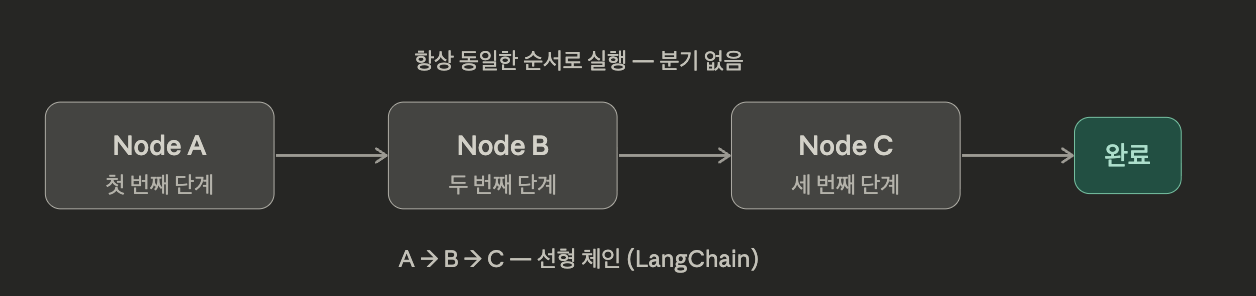

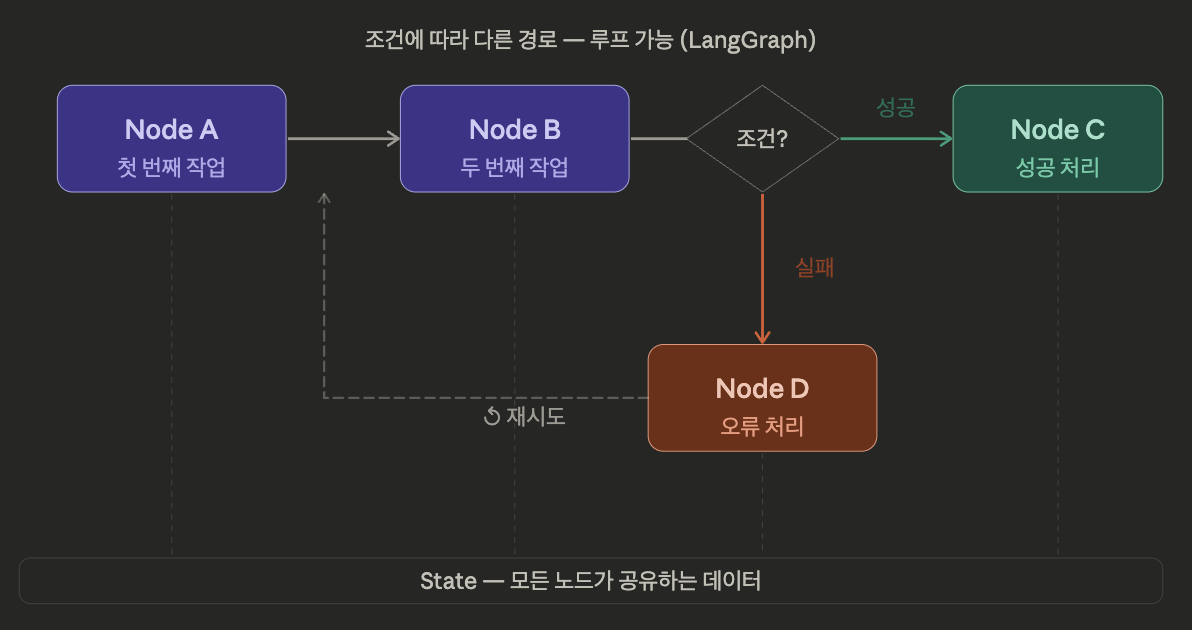

## 기본 그래프

LLM 하나를 노드로 사용하는 가장 기본적인 그래프를 만들어보자.

`START`와 `END`는 그래프의 시작과 종료 지점을 나타내는 특수 노드이다.

```
START → chatbot → END
```

### State 정의

State는 그래프 전체에서 공유하는 데이터 구조다. `TypedDict`로 정의한다.

`TypedDict`는 Python 표준 라이브러리(`typing`)에 포함된 타입으로, **딕셔너리의 키와 값 타입을 명시**할 수 있다.

```python
# 일반 dict — 어떤 키가 있는지, 값이 무슨 타입인지 알 수 없음
state = {"name": "홍길동", "age": 30}

# TypedDict — 키 이름과 타입이 명확
class State(TypedDict):
    name: str
    age: int
```

런타임에는 일반 `dict`와 동일하게 동작하지만, IDE 자동완성과 타입 검사를 지원한다.

In [4]:
class State(TypedDict):
    question: str
    answer: str

### Node 정의

노드는 **Python 함수**다. State를 받아서 업데이트할 내용을 반환한다.

In [5]:
llm = ChatGoogleGenerativeAI(model=MODEL_NAME)


def chatbot(state: State):
    response = llm.invoke(state["question"])
    return {"answer": response.text}


노드 함수의 패턴은 항상 동일하다.

1. `state`를 인자로 받는다
2. state에서 필요한 데이터를 꺼내 처리한다
3. 업데이트할 필드를 dict로 반환한다

반환된 dict는 State에 **병합**된다.

### Graph 구성 + Edge 연결

In [6]:
# 그래프 생성
graph_builder = StateGraph(State)

# 노드 추가 (이름, 함수)
graph_builder.add_node("chatbot", chatbot)

# 엣지 추가
graph_builder.add_edge(START, "chatbot")  # 시작 → chatbot
graph_builder.add_edge("chatbot", END)    # chatbot → 종료

# 컴파일
graph = graph_builder.compile()

순서를 정리하면:

1. `StateGraph(State)` — State 스키마로 그래프 생성
2. `add_node(이름, 함수)` — 노드 등록
3. `add_edge(출발, 도착)` — 노드 간 연결
4. `compile()` — 실행 가능한 그래프로 변환

### 시각화

LangGraph는 그래프 구조를 이미지로 시각화할 수 있다.

`IPython.display`는 Jupyter 노트북 전용 모듈이다. 일반 Python 스크립트에서는 파일로 저장해야 한다.

```python
# .py 파일에서 사용할 경우
png_data = graph.get_graph().draw_mermaid_png()
with open("graph.png", "wb") as f:
    f.write(png_data)
```

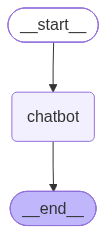

In [7]:
display(Image(graph.get_graph().draw_mermaid_png()))

### 실행

`graph.invoke(초기 State)`는 그래프를 실행하고 모든 노드의 처리가 끝난 뒤 최종 State를 반환한다.

In [8]:
result = graph.invoke({"question": "LangGraph가 뭐야?"})
print(result["answer"])

**LangGraph(랭그래프)**는 LangChain(랭체인) 개발팀이 만든 **복잡하고 순환적인(Cyclic) AI 에이전트 및 다중 에이전트(Multi-Agent) 애플리케이션을 구축하기 위한 프레임워크**입니다.

쉽게 말해, **"AI가 스스로 생각하고, 행동하고, 실패하면 다시 시도하는 복잡한 작업 흐름을 제어하는 도구"**입니다.

---

### 1. 왜 LangGraph가 나왔을까요? (기존 LangChain과의 차이)

기존의 LangChain은 주로 **'단방향 순서(DAG, 단방향 아사이클릭 그래프)'**로 일했습니다.
* 예: `질문 입력` ➡️ `문서 검색` ➡️ `답변 생성` (끝)

하지만 실제 복잡한 AI 에이전트를 만들 때는 **'되돌아가기'나 '반복(Loop)'**이 필요합니다.
* 예: `코드 작성` ➡️ `검증` ➡️ **(오류 발생!)** ➡️ `다시 코드 수정` ➡️ `검증` ➡️ `완료`

기존 LangChain으로는 이런 **순환 구조(Loop)**나 복잡한 조건문, 상태 관리를 구현하기가 매우 까다로웠습니다. 이를 해결하기 위해 그래프(Graph) 구조를 도입한 **LangGraph**가 탄생했습니다.

---

### 2. LangGraph의 핵심 개념 3가지

LangGraph는 시스템을 하나의 **'지도(Graph)'**로 표현합니다.

1. **State (상태)**
   * 그래프 전체에서 공유되는 **'메모리'**입니다. 
   * 대화 내역, 현재 실행 결과, AI의 계획 등이 상태에 저장되며 노드 간에 전달됩니다.
2. **Nodes (노드)**
   * 실제로 **일을 하는 주체(함수 또는 LLM)**입니다.
   * 예: "검색해 오는 노드", "글을 작성하는 노드", "코드를 실행하는 노드" 등
3. **Edges (엣지)**
   * 노드와 노드를 연결하는 **'규칙/조건'**입니다.
   * 조건부 엣지(Conditional Edge)를 사용하면 "AI의 답변 결과가 만족스럽지 않으면 노드 

## 그래프: 조건부 분기

LangGraph의 조건부 엣지를 사용해 **조건 분기**를 구현해보자.

시나리오: 사용자 입력의 언어를 감지해서 한국어면 한국어로, 영어면 영어로 답변하는 그래프. 입력 언어는 한국어 또는 영어라고 가정한다.

```
START → detect_language → 한국어? → answer_ko → END
                          영어?  → answer_en → END
```

In [10]:
class RouterState(TypedDict):
    question: str
    language: str
    answer: str

In [11]:
def detect_language(state: RouterState):
    question = state["question"]
    result = llm.invoke(f"다음 문장의 언어가 한국어면 'ko', 영어면 'en'으로만 답해: {question}")
    return {"language": result.text.strip().lower()}


def answer_ko(state: RouterState):
    result = llm.invoke(f"한국어로 답변해줘: {state['question']}")
    return {"answer": result.text}


def answer_en(state: RouterState):
    result = llm.invoke(f"Answer in English: {state['question']}")
    return {"answer": result.text}

`add_edge`는 다음 노드가 고정되어 있지만, `add_conditional_edges`는 **함수의 반환값에 따라 다음 노드가 결정**된다.

```python
# 고정 연결
add_edge("A", "B")  # A 다음은 항상 B

# 조건부 연결
add_conditional_edges(
    "A",              # 출발 노드
    routing_function,  # State를 받아 문자열을 반환하는 함수
    {                  # 반환값 → 도착 노드 매핑
        "go_b": "B",
        "go_c": "C",
    },
)
```

In [12]:
def route_by_language(state: RouterState):
    """language에 따라 다음 노드를 결정하는 라우팅 함수"""
    if "ko" in state["language"]:
        return "ko"
    else:
        return "en"


graph_builder = StateGraph(RouterState)

graph_builder.add_node("detect_language", detect_language)
graph_builder.add_node("answer_ko", answer_ko)
graph_builder.add_node("answer_en", answer_en)

graph_builder.add_edge(START, "detect_language")
graph_builder.add_conditional_edges(
    "detect_language",    # 출발 노드
    route_by_language,    # 라우팅 함수
    {                     # 반환값 → 도착 노드 매핑
        "ko": "answer_ko",
        "en": "answer_en",
    },
)
graph_builder.add_edge("answer_ko", END)
graph_builder.add_edge("answer_en", END)

router_graph = graph_builder.compile()

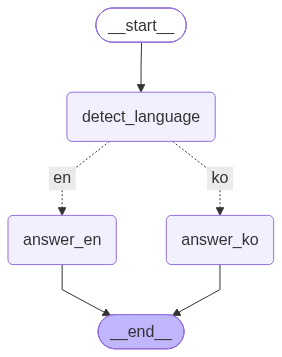

In [13]:
display(Image(router_graph.get_graph().draw_mermaid_png()))

In [14]:
# 한국어 입력
result = router_graph.invoke({"question": "파이썬의 장점이 뭐야?"})
print(f"언어: {result['language']}")
print(f"답변: {result['answer'][:200]}")
print()

# 영어 입력
result = router_graph.invoke({"question": "What are the benefits of Python?"})
print(f"언어: {result['language']}")
print(f"답변: {result['answer'][:200]}")

언어: ko
답변: 파이썬(Python)은 현재 전 세계에서 가장 인기 있는 프로그래밍 언어 중 하나입니다. 파이썬이 가진 주요 장점들을 정리해 드릴게요.

---

### 1. 쉬운 문법과 높은 가독성
* **인간의 언어와 유사:** 파이썬 문법은 영문장과 비슷하게 직관적이어서 프로그래밍 초보자도 쉽게 배울 수 있습니다.
* **깔끔한 코드:** 중괄호(`{}`) 대신 **

언어: en
답변: Python is one of the most popular and widely used programming languages in the world today. Its popularity stems from a wide range of benefits for both beginners and experienced developers. 

Here are


`invoke`가 그래프 실행이 끝난 뒤 최종 상태를 반환한다면, `graph.stream()`은 각 노드가 실행된 뒤의 상태 업데이트를 순서대로 반환한다. 이를 통해 조건에 따라 어떤 노드가 실행되었는지 확인할 수 있다.

`llm.stream()`이 모델의 응답을 토큰 또는 콘텐츠 조각 단위로 전달하는 것과 달리, `graph.stream()`은 기본적으로 상태 업데이트를 노드 단위로 반환한다.

In [15]:
for event in router_graph.stream({"question": "파이썬의 장점이 뭐야?"}):
    for node_name, value in event.items():
        print(f"[{node_name}] {value}")
        print()

[detect_language] {'language': 'ko'}

[answer_ko] {'answer': '파이썬(Python)은 현재 전 세계에서 가장 인기 있는 프로그래밍 언어 중 하나입니다. 파이썬이 가진 주요 장점은 다음과 같습니다.\n\n---\n\n### 1. 배우기 쉽고 가독성이 높음\n* **직관적인 문법:** 파이썬의 문법은 인간의 언어(영어)와 매우 유사하여 초보자도 쉽게 이해할 수 있습니다.\n* **높은 가독성:** 코드가 간결하고 들여쓰기(Indentation)를 강제하기 때문에, 누가 작성하더라도 코드가 깔끔하고 읽기 쉽습니다.\n\n### 2. 풍부한 라이브러리와 생태계\n* **\'바퀴를 재발명할 필요가 없다\':** 이미 수많은 개발자들이 만들어 놓은 유용한 도구(라이브러리/패키지)가 엄청나게 많습니다.\n* **특화 분야:**\n  * **인공지능/머신러닝:** TensorFlow, PyTorch, Scikit-learn\n  * **데이터 분석/과학:** Pandas, NumPy, Matplotlib\n  * **웹 개발:** Django, Flask, FastAPI\n  * **크롤링/스크래핑:** BeautifulSoup, Selenium\n\n### 3. 높은 생산성 (빠른 개발 속도)\n* 다른 언어(C, C++, Java 등)에 비해 훨씬 적은 양의 코드로 동일한 기능을 구현할 수 있습니다.\n* 아이디어를 빠르게 실행해보고 시제품(Prototype)을 만드는 데 최적화되어 있습니다.\n\n### 4. 뛰어난 범용성 (다양한 활용 분야)\n* 특정 분야에만 국한되지 않고 **웹 개발, 데이터 분석, 인공지능, 업무 자동화, 게임 개발, 네트워크 프로그래밍** 등 거의 모든 분야에서 활용할 수 있습니다.\n\n### 5. 거대한 커뮤니티와 강력한 지원\n* 전 세계에 파이썬 사용자가 매우 많기 때문에, 공부하다가 막히는 부분이 생기면 구글링이나 커뮤니티(Stack Overflow 등)를 통해 **해결 방법을 빠르게 

`graph.stream()`은 기본적으로 각 노드가 반환한 State 업데이트를 전달한다. 각 단계의 전체 State를 확인하려면 `stream_mode="values"`를 지정한다.

In [16]:
for state in router_graph.stream(
    {"question": "파이썬의 장점이 뭐야?"},
    stream_mode="values",
):
    print(state)
    print()

{'question': '파이썬의 장점이 뭐야?'}

{'question': '파이썬의 장점이 뭐야?', 'language': 'ko'}

{'question': '파이썬의 장점이 뭐야?', 'language': 'ko', 'answer': '파이썬(Python)은 현재 전 세계에서 가장 인기 있는 프로그래밍 언어 중 하나입니다. 파이썬이 이토록 사랑받는 주요 장점들은 다음과 같습니다.\n\n---\n\n### 1. 배우기 쉽고 가독성이 뛰어남\n* **간결한 문법:** 파이썬은 인간의 언어(영어)와 유사한 직관적인 문법을 가지고 있습니다. \n* **높은 가독성:** 코드가 깔끔하고 명확하여 다른 사람이 작성한 코드를 이해하기 쉽고 유지보수가 용이합니다. 초보자가 프로그래밍을 시작할 때 가장 추천되는 이유입니다.\n\n### 2. 높은 생산성과 빠른 개발 속도\n* 다른 언어(C, C++, Java 등)에 비해 **같은 기능을 훨씬 적은 양의 코드로 구현**할 수 있습니다.\n* 아이디어를 빠르게 프로그램으로 만들어 테스트해 볼 수 있어(프로토타이핑), 스타트업이나 연구 분야에서 선호합니다.\n\n### 3. 풍부한 라이브러리와 생태계 (Batteries Included)\n* 파이썬은 "필요한 것은 이미 다 들어있다"는 철학을 가지고 있습니다.\n* **데이터 분석 및 AI:** Pandas, NumPy, TensorFlow, PyTorch, Scikit-learn 등\n* **웹 개발:** Django, Flask, FastAPI 등\n* **웹 크롤링/자동화:** BeautifulSoup, Selenium 등\n* 이미 잘 만들어진 패키지가 많아 처음부터 직접 만들지 않고 가져다 쓰기만 해도 강력한 기능을 구현할 수 있습니다.\n\n### 4. 다양한 분야에서의 범용성\n파이썬 하나만 배워두면 매우 다양한 분야에 적용할 수 있습니다.\n* **인공지능 및 머신러닝** (현재 시장 점유율 1위)\n* **데이터 과학 및 통계 분석**\n* **웹 백엔드 

### 그래프: 루프

LangGraph의 조건부 엣지를 사용해 **반복과 종료 조건**을 구현해보자.

State의 `count`를 1씩 증가시키고, 5가 되면 반복을 종료한다.

```
START → increment → count < 5 → increment로 돌아감
                   count ≥ 5 → END
```

In [17]:
class CountState(TypedDict):
    count: int


def increment(state: CountState):
    return {"count": state["count"] + 1}


def route_by_count(state: CountState):
    if state["count"] >= 5:
        return "end"
    return "continue"


count_builder = StateGraph(CountState)
count_builder.add_node("increment", increment)

count_builder.add_edge(START, "increment")
count_builder.add_conditional_edges(
    "increment",
    route_by_count,
    {
        "continue": "increment",
        "end": END,
    },
)

count_graph = count_builder.compile()

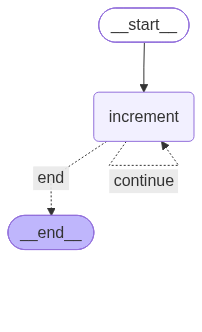

In [18]:
display(Image(count_graph.get_graph().draw_mermaid_png()))

In [19]:
for event in count_graph.stream({"count": 0}):
    print(event)

{'increment': {'count': 1}}
{'increment': {'count': 2}}
{'increment': {'count': 3}}
{'increment': {'count': 4}}
{'increment': {'count': 5}}


핵심 포인트:

- `increment` 노드가 실행될 때마다 State의 `count`가 1씩 증가한다.
- `route_by_count`는 State를 변경하지 않고 다음 경로만 결정한다.
- `"continue": "increment"` 연결을 통해 이전 노드로 돌아갈 수 있다.
- `count`가 5 이상이면 `END`로 이동해 반복을 종료한다.

### 언제 Node를 나눌까?

LangGraph에서는 보통 다음 기준으로 Node를 나눈다.

- **책임이 분리되는가?** 서로 다른 역할을 수행하는 작업은 별도의 Node로 나눈다.
- **상태가 의미 있게 바뀌는가?** 중간 결과를 State에 저장하고 다음 단계에서 사용해야 한다면 Node를 나누는 것이 좋다.
- **분기나 재시도가 필요한가?** 결과에 따라 경로가 달라지거나 특정 작업만 다시 실행해야 한다면 독립된 Node로 구성한다.
- **관찰이 필요한가?** 실행 결과, 소요 시간, 오류 등을 단계별로 확인해야 하는 작업은 별도의 Node로 나눈다.

앞의 조건부 분기 예제는 언어 감지와 답변 생성을, 반복 예제는 숫자 추측과 결과 확인을 각각 별도의 Node로 나누었다. 반대로 항상 함께 실행되고 개별적인 분기, 재시도, 관찰이 필요 없는 작은 작업은 하나의 Node 안에서 처리해도 된다.


### Reducer

노드가 반환한 값은 기본적으로 기존 State 값을 덮어쓴다. State 필드에 **Reducer**를 지정하면 기존 값과 새 값을 어떻게 합칠지 정의할 수 있다.

`Annotated`는 Python에서 타입에 부가 정보를 붙이는 문법이다. `Annotated[기본 타입, 메타데이터]` 형식으로 사용하며, 기본 타입은 그대로 유지된다.

LangGraph는 이 메타데이터 위치의 함수를 Reducer로 사용한다. 따라서 `Annotated[list, add_messages]`는 값의 타입이 `list`이고, State를 업데이트할 때 `add_messages`로 기존 값과 새 값을 합친다는 뜻이다.

```python
name: str                              # reducer 없음 → 새 값으로 덮어쓰기
messages: Annotated[list, add_messages] # 대화 메시지 누적
logs: Annotated[list, operator.add]     # 기존 리스트와 새 리스트 연결
```

In [ ]:
class ReducerDemo(TypedDict):
    name: str                                    # reducer 없음 → 덮어쓰기
    messages: Annotated[list, add_messages]       # add_messages → 대화 메시지 누적
    logs: Annotated[list, operator.add]           # operator.add → 리스트 이어붙이기


def step_a(state: ReducerDemo):
    return {
        "name": "A가 설정",
        "messages": [HumanMessage(content="안녕")],
        "logs": ["A 실행"],
    }


def step_b(state: ReducerDemo):
    return {
        "name": "B가 덮어씀",
        "messages": [AIMessage(content="반가워!")],
        "logs": ["B 실행"],
    }


def step_c(state: ReducerDemo):
    return {
        "name": "C가 덮어씀",
        "messages": [HumanMessage(content="잘 가!")],
        "logs": ["C 실행"],
    }


demo_builder = StateGraph(ReducerDemo)
demo_builder.add_node("a", step_a)
demo_builder.add_node("b", step_b)
demo_builder.add_node("c", step_c)
demo_builder.add_edge(START, "a")
demo_builder.add_edge("a", "b")
demo_builder.add_edge("b", "c")
demo_builder.add_edge("c", END)

demo_graph = demo_builder.compile()
display(Image(demo_graph.get_graph().draw_mermaid_png()))

result = demo_graph.invoke({"messages": [], "logs": []})

print(f"name: {result['name']}")
print(f"logs: {result['logs']}")
print(f"messages:")
for msg in result["messages"]:
    print(f"  {msg.type}: {msg.content}")

reducer 선택 가이드:

| 상황 | reducer | 동작 |
|------|---------|------|
| 최신 값만 필요 (이름, 최종 판정 등) | 없음 | 덮어쓰기 |
| 대화 메시지 누적 | `add_messages` | 메시지 형식으로 처리하며 누적 |
| 로그, 결과 목록 누적 | `operator.add` | 단순 리스트 이어붙이기 (`+`) |

단순히 리스트를 이어 붙이는 경우에는 `operator.add`로도 메시지를 누적할 수 있다. `add_messages`는 여러 입력 형식을 메시지 객체로 변환해 처리하는 메시지 전용 Reducer이므로 대화 기록에는 주로 `add_messages`를 사용한다.

State 스키마를 잘 설계하면 이후 모든 노드가 깔끔해진다. 이 부분은 앞으로 계속 반복된다.

## Chain vs LangGraph

| | Chain | LangGraph |
|---|---|---|
| 흐름 | 직선 (A → B → C) | 분기 + 루프 가능 |
| 상태 | 이전 단계 출력만 전달 | State로 전체 공유 |
| 제어 | 고정된 순서 | 조건에 따라 동적 결정 |
| 디버깅 | 각 단계 출력 확인 | 그래프 시각화 + 노드별 트레이싱 |
| 적합한 경우 | 단순 파이프라인 | 분기, 반복, 상태 관리가 필요한 경우 |

### 실습 1: 감정 분석 라우터

사용자의 문장을 받아 감정을 분석하고, 긍정이면 긍정 응답, 부정이면 위로 응답을 생성하는 그래프를 만들어보자.

```
START → analyze → 긍정? → respond_positive → END
                   부정? → respond_negative → END
```

**테스트 입력**:
```python
sentiment_graph.invoke({"text": "오늘 승진했어! 너무 기뻐!"})
sentiment_graph.invoke({"text": "프로젝트가 엎어졌어... 힘들다"})
```

In [47]:
class SentimentState(TypedDict):
    text: str
    sentiment: str
    response: str

def analyze(state: SentimentState):
    text = state['text']
    result = llm.invoke(f"다음 문장을 받아 감정을 분석하고, 긍정이면 'positive', 부정이면 'negative' 응답만 출력해 : {text}")
    return {"sentiment":result.text}

def respond_positive(state: SentimentState):
    text = state['text']
    result = llm.invoke(f"사용자의 말의 공감하고 긍정적인 응답을 해줘 : {text}")

    return {"response": result.text}

def respond_negative(state: SentimentState):
    text = state['text']
    result = llm.invoke(f"사용자의 말이 부정이면 위로 응답을 해줘 : {text}")
    return {"response": result.text}

def route_by_sentiment(state: SentimentState):
    """sentiment에 따라 다음 노드를 결정"""
    if "positive" in state["sentiment"]:
        return "positive"
    else:
        return "negative"
    
graph_builder = StateGraph(SentimentState)

graph_builder.add_node("analyze", analyze)
graph_builder.add_node("respond_positive", respond_positive)
graph_builder.add_node("respond_negative", respond_negative)

graph_builder.add_edge(START, "analyze")

graph_builder.add_conditional_edges(
    "analyze",
    route_by_sentiment,
    {
        "positive": "respond_positive",
        "negative": "respond_negative",
    },
)

graph_builder.add_edge("respond_positive", END)
graph_builder.add_edge("respond_negative", END)


sentiment_graph = graph_builder.compile()

In [ ]:
# 강사님 풀이
from langchain_core.prompts import ChatPromptTemplate, PromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_core.messages import AIMessage, HumanMessage, SystemMessage

class State(TypedDict):
    text: str
    sentiment: str
    response: str

def analyze(state: State):
    """감정 분석 -> 긍정, 부정으로 나누는 함수."""
    text = state['text']

    prompt = PromptTemplate.from_template(
    "다음 <text>에 대해서 감정을 분석해줘. 긍정이면 'positive' 부정이면 'negative'로 응답해줘. <text>{text}</text>"
)
    chain = prompt | llm | StrOutputParser()

    response = chain.invoke({'text' : text})

    return {'sentiment' : response}

def response_positive(state: State):
    """사용자의 문장에 대해서 긍정적인 답변을 하는 함수"""
    text = state['text']

    response = llm.invoke(f"다음 <text>에 대해서 긍정적인 답변을 해줘. <text>{text}</text>")
    return {'response' : response.text}

def response_negative(state: State):
    """사용자의 문장에 대해서 위로의 답변을 하는 함수"""
    text = state['text']

    response = llm.invoke(f"다음 <text>에 대해서 위로의 답변을 해줘. <text>{text}</text>")
    return {'response' : response.text}

def route_by_sentiment(state: State):
    """사용자의 감정에 따라 다른 값을 return"""
    sentiment = state["sentiment"]
    # 혹시 모를 오타 스러운것을 방지하기 위해서 여백 제거 -> 소문자로 변경.
    # structured output을 사용하면 손쉽게 해결될 수 있음..
    sentiment = sentiment.strip().lower()
    # analyze에서 실시한 결과에 따라 구분.

    if sentiment == "positive":
        return "positive"
    else:
        return "negative"

    # return sentiment

graph = StateGraph(State)

# 노드 추가
graph.add_node("analyze", analyze)
graph.add_node("response_positive", response_positive)
graph.add_node("response_negative", response_negative)

graph.add_edge(START, "analyze")
graph.add_conditional_edges(
    "analyze",
    route_by_sentiment,
    {
       "positive" : "response_positive",
       "negative" : "response_negative"
    }
)

graph = graph.compile()

In [ ]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
for event in graph.stream({'text' : "와! 오늘 승진함!"}):
    for node_name, value in event.items():
        print(f"[{node_name}] {value}")
        print()

In [49]:
sentiment_graph.invoke({"text": "오늘 승진했어! 너무 기뻐!"})['response']
# sentiment_graph.invoke({"text": "프로젝트가 엎어졌어... 힘들다"})

{'text': '오늘 승진했어! 너무 기뻐!',
 'sentiment': 'positive',
 'response': '와, 정말 진심으로 축하드려요!! 🎉🎉 \n오늘 승진하셨다니 제가 다 가슴이 뿌듯하고 기쁘네요!\n\n그동안 묵묵히 노력하고 열심히 달려온 시간들이 이렇게 멋진 결실을 맺은 거잖아요. 얼마나 기쁘고 보람차실까요! 오늘 승진은 그동안 고생한 당신에게 주는 최고의 선물이에요.\n\n오늘만큼은 그동안의 피로도 싹 날려버리시고, 맛있는 것도 드시면서 이 기쁨을 마음껏 누리셨으면 좋겠습니다! 스스로에게 "그동안 정말 수고했어!"라고 꼭 아낌없이 칭찬해 주세요.\n\n새로운 자리에서도 당신의 능력과 열정이 더욱 빛을 발할 거라고 믿어요. 다시 한번 승진을 축하드립니다! 최고예요! 👏✨'}

### 실습 2: 숫자 맞히기

LLM이 1~100 사이의 숫자를 추측하고, 정답이 아니면 범위를 좁혀 다시 시도하는 그래프를 만들어보자.

```
START → guess → check → 정답? → END
                  ↑      오답? → guess로 돌아감
```

`check` 노드는 추측값이 정답보다 작으면 `low`를 높이고, 크면 `high`를 낮춘다. 예를 들어 정답이 37일 때 50을 추측하면 다음 추측 범위는 1~49가 된다.

**테스트 입력**:
```python
guess_graph.stream({"target": 37})
```

In [45]:
class GuessState(TypedDict):
    guess: int
    low: int
    high: int
    target: int

def guess(state: GuessState):
    low = state.get('low', 1)
    high = state.get('high', 100)
    result = llm.invoke(f"{low}부터 {high} 사이의 정수 숫자 하나만 추측해서 출력, 소수는 절대 출력하지 마 ")
    return {"guess":int(result.content[0]['text'].strip()), "low":low, "high": high}

def check(state: GuessState):
    guess = state['guess']
    target = state['target']

    if guess < target:
        return {"low": guess + 1}

    elif guess > target:
        return {"high": guess - 1}

    else:
        return {}

def route_by_guess(state: GuessState):
    guess = state['guess']
    target = state['target']

    if guess == target:
        return "end"
    else:
        return "retry"


graph_builder = StateGraph(GuessState)

graph_builder.add_node("guess", guess)
graph_builder.add_node("check", check)

graph_builder.add_edge(START, "guess")
graph_builder.add_edge("guess", "check")

graph_builder.add_conditional_edges(
    "check",
    route_by_guess,
    {
        "retry": "guess",
        "end": END,
    }
)

guess_graph = graph_builder.compile()

In [46]:
for event in guess_graph.stream({"target": 37}):
    print(event)

{'guess': {'guess': 42, 'low': 1, 'high': 100}}
{'check': {'high': 41}}
{'guess': {'guess': 24, 'low': 1, 'high': 41}}
{'check': {'low': 25}}
{'guess': {'guess': 28, 'low': 25, 'high': 41}}
{'check': {'low': 29}}
{'guess': {'guess': 35, 'low': 29, 'high': 41}}
{'check': {'low': 36}}
{'guess': {'guess': 38, 'low': 36, 'high': 41}}
{'check': {'high': 37}}
{'guess': {'guess': 36, 'low': 36, 'high': 37}}
{'check': {'low': 37}}
{'guess': {'guess': 37, 'low': 37, 'high': 37}}
{'check': None}


In [ ]:
# 강사님 풀이


# 1. target을 줍니다. 37
# 2. llm에게 1 ~ 100 까지 추측하라고 합니다.
    # => 첫번째 노드 : 추측하는 노드
# 3. 뭔가를 추측할꺼에요. 50
# 4. 틀렸어. 1 ~ 49로 바꿔.
    # => 두번째 노드 : 틀린지 맞는지 확인 / high, low를 바꾸는 노드.
    # 노드를 나누는 기준 : 역할 / 책임 / state변경.
    # 사실은 하나의 노드 + 하나의 route_function.
# 5. llm에게 1 ~ 49까지 추측하라고 합니다.
# 6. 뭔가를 추측할꺼에요.

MAX_ATTEMPT = 5

class GuessState(TypedDict):
    target: int
    low: int
    high: int
    guess: int
    attempt: int

def guess(state: GuessState):
    low = state['low']
    high = state['high']
    # low = state.get('low', 1)
    # high = state.get('high', 100)
    attempt = state.get('attempt', 0)

    # 시도에 대한 변수
    print(f'{attempt + 1} 번째 시도')
    response= llm.invoke(f"{low} ~ {high}까지의 숫자를 골라줘. 단, 정수만 답변해.")
    return {'guess' : int(response.text), 'attempt' : attempt + 1}

def route_success(state: GuessState):
    target = state['target']
    guess = state['guess']
    attempt = state['attempt']

    if attempt >= MAX_ATTEMPT:
        print('실패')
        return 'end'

    if target == guess:
        return 'end'
    
    return 'continue'

# 아래의 두 함수는 "guess 값을 확인해서 맞으면 end, 틀리면 guess로 옮기기."
# 그 과정에서 low, high 변경하기.
def change_high_low(state: GuessState):
    target = state['target']
    guess = state['guess']

    if target > guess:
        return {'low' : guess + 1}
    if target < guess:
        return {'high' : guess - 1}


guess_graph_builder = StateGraph(GuessState)

guess_graph_builder.add_node('guess', guess)
guess_graph_builder.add_node('change_high_low', change_high_low)

guess_graph_builder.add_edge(START, 'guess')
guess_graph_builder.add_conditional_edges(
    'guess',
    route_success,
    {
        'end' : END,
        'continue' : 'change_high_low'
    }
)
guess_graph_builder.add_edge('change_high_low', 'guess')

guess_graph = guess_graph_builder.compile()


In [ ]:
for event in guess_graph.stream({'target': 37, 'low': 1, 'high': 100}):
    for node_name, value in event.items():
        print(f"[{node_name}] {value}")
        print()

### 실습 3: 글 작성 → 검토 → 재작성

주제를 받아 짧은 글을 작성하고, 검토 후 품질이 부족하면 피드백을 반영해 다시 작성하는 그래프를 만들어보자.

```
START → write → review → 통과? → END
                         미흡? → write로 돌아감
```

**테스트 입력**:
```python
writing_graph.stream({"topic": "AI가 교육에 미치는 영향"})
```

In [ ]:
class WritingState(TypedDict):
    topic: str
    result: str
    success: str
    fail: str

def write(state : WritingState):
    topic = state['topic']
    fail = state.get("fail", "")


    if fail:
        result = llm.invoke(
            f"""
            다음 주제에 대해서 짧은 글을 다시 작성해줘.

            주제:
            {topic}

            이전 검토 피드백:
            {fail}

            위 피드백을 반영해서 글의 품질을 개선해줘.
            """
        )
    else:
        result = llm.invoke(f"다음 주제에 대해서 짧은 글을 작성해줘 : {topic}")
    return {"result": result.text}

def review(state: WritingState):
    result = state['result']

    review_result = llm.invoke(f"다음 글의 품질을 검토하고 품질이 좋으면 'success'만 출력하고, 좋지 않으면 'fail: 개선해야 할 내용'을 출력해 : {result}")
    review_result = review_result.text.strip().lower()
    if review_result == "success":
        return {"success": "success", "fail":""}
    return {"success": "", "fail": review_result}

def route_by_succes(state: WritingState):
    if state.get("success") == "success":
        return "success"
    return "fail"

graph = StateGraph(WritingState)

graph.add_node("write", write)
graph.add_node("review", review)
graph.add_edge(START, "write")
graph.add_edge("write", "review")
graph.add_conditional_edges(
    'review',
    route_by_succes,
    {
        "success" : END,
        "fail" : "write"
    }
)

topic_graph = graph.compile()

In [63]:
for event in topic_graph.stream({"topic": "그것에 대해서 적당히"}):
    print(event)

{'write': {'result': "**제목: '적당히'라는 가장 어려운 경지**\n\n'적당히 해라'라는 말은 때로 성의가 없거나 소극적인 태도로 오해받곤 합니다. 하지만 삶을 살아가다 보면 깨닫게 됩니다. 세상에서 가장 구현하기 힘든 감각이 바로 '적당히'라는 것을요.\n\n의욕이 너무 넘치면 번아웃이 오고, 의욕이 너무 없으면 삶이 무기력해집니다. 사랑도, 노력도, 심지어 타인을 향한 친절조차도 지나치면 부담이 되고 부족하면 서운함이 됩니다. \n\n결국 '적당히'라는 것은 대충 하는 게 아닙니다. 나의 에너지가 방전되지 않으면서도 성과를 내는 지점, 상대방과 내가 모두 편안함을 느끼는 최적의 거리를 찾는 **'섬세한 균형의 기술'**입니다.\n\n뜨거워서 데이지도 않고, 차가워서 식지도 않는 온도를 유지하는 것. 오늘 하루는 너무 과지도, 부족하지도 않게, 나 자신을 지킬 수 있을 만큼 딱 '적당히' 흘러갔으면 좋겠습니다."}}
{'review': {'success': 'success', 'fail': ''}}


In [ ]:
## 강사님 풀이

from typing import Literal
from pydantic import BaseModel
# 1. 글 작성.
# 2. 검토 + 미리 피드백 만들어 두기.
# 3-a 품질이 좋으면 끝남.
# 3-b 품질이 부족하면 피드백을 반영해 다시 작성. -> 1.로 돌아가기. 이번에는 피드백이 있기 때문에 1에서 피드백을 추가해서 진행한다

class WriteState(TypedDict):
    topic: str
    sentense: str
    feedback: str
    result: Literal['pass', 'fail']


class ReviewResult(BaseModel):
    result: Literal['pass', 'fail']
    feedback : str

llm_with_review_result = llm.with_structured_output(ReviewResult)

def write(state: WriteState):
    topic = state['topic']

    # 위의 문제는 pass, fail이면 충분하지면
    # 여기서는 feedback, result를 둘다 채워야하기 때문에 structued output을 사용.
    response = llm.invoke(f'{topic}을 주제로 하는 간다한 글을 작성해줘.')

    return {'sentense' : response.text}
    

def review(state: WriteState):
    topic = state['topic']
    text = state['sentense']

    # 위의 문제는 pass, fail이면 충분하지면
    # 여기서는 feedback, result를 둘다 채워야하기 때문에 structued output을 사용.
    response = llm_with_review_result.invoke(f"""
다음 <text>는 <topic>을 주제로 한 글이야. 다음 글에 대해서 검토해줘.
- result에는 "pass" 또는 "fail"을 담아줘.
- feeback에는 그렇게 생각한 이유를 명시해줘.

<topic>
{topic}
</topic>


<text>
{text}
</text>

""")
    return {'result' : response.result, 'feedback' : response.feedback }

def route_by_result(state: WriteState):
    result = state['result']

    if result == 'pass':
        return 'pass'
    else:
        return 'fail'
    
    # return state['result']

write_graph_builder = StateGraph(WriteState)

write_graph_builder.add_node('write', write)
write_graph_builder.add_node('review', review)

write_graph_builder.add_edge(START, 'write')
write_graph_builder.add_edge('write', 'review')

write_graph_builder.add_conditional_edges(
    'review',
    route_by_result,
    {
        'pass' : END,
        'fail' : 'write'
    }
)

write_graph = write_graph_builder.compile()

display(Image(write_graph.get_graph().draw_mermaid_png()))


In [ ]:
for event in write_graph.stream({'topic' : "ai agent와 랭그래프"}):
    for node_name, value in event.items():
        print(f"[{node_name}] {value}")
        print()

##### 첫번째 응답을 일부러 짧게 만들어서 fail이 나오도록 해봅시다.


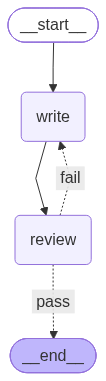

In [65]:
from typing import Literal
from pydantic import BaseModel
# 1. 글 작성.
# 2. 검토 + 미리 피드백 만들어 두기.
# 3-a 품질이 좋으면 끝남.
# 3-b 품질이 부족하면 피드백을 반영해 다시 작성. -> 1.로 돌아가기. 이번에는 피드백이 있기 때문에 1에서 피드백을 추가해서 진행한다

class WriteState(TypedDict):
    topic: str
    sentense: str
    feedback: str
    result: Literal['pass', 'fail']
    attempt: int

class ReviewResult(BaseModel):
    result: Literal['pass', 'fail']
    feedback : str

llm_with_review_result = llm.with_structured_output(ReviewResult)

def write(state: WriteState):
    topic = state['topic']
    # 초기에는 없기 때문에 .get과 default 값으로 가져온다.
    sentense = state.get('sentense', "")
    feedback = state.get('feedback', "")
    attempt = state.get('attempt', 0)

    attempt += 1

    if attempt == 1:
        return {'sentense' : f"{topic}은 아주 좋은 것이야!", 'attempt': attempt}


    # 위의 문제는 pass, fail이면 충분하지면
    # 여기서는 feedback, result를 둘다 채워야하기 때문에 structued output을 사용.
    response = llm.invoke(f"""
주제 : {topic}
feedback : {feedback}
draft : {sentense}

draft는 이전 글이야. feedback을 바탕으로 topic에 대해서 간단한 글을 작성해줘.
draft와 feedback이 비어있다면 topic에 대해서 간단한 글을 작성해줘.

""")
    # 이렇게 draft와 feedback에 따라서 
    # 1. 프롬프트로 분리
    # 2. if문으로 node 내에서 분리
    # 3. node 자체를 분리

    return {'sentense' : response.text, 'attempt': attempt}
    

def review(state: WriteState):
    topic = state['topic']
    text = state['sentense']

    # 위의 문제는 pass, fail이면 충분하지면
    # 여기서는 feedback, result를 둘다 채워야하기 때문에 structued output을 사용.
    response = llm_with_review_result.invoke(f"""
다음 <text>는 <topic>을 주제로 한 글이야. 다음 글에 대해서 검토해줘.
- result에는 "pass" 또는 "fail"을 담아줘.
- feeback에는 그렇게 생각한 이유를 명시해줘.

<topic>
{topic}
</topic>


<text>
{text}
</text>

""")
    return {'result' : response.result, 'feedback' : response.feedback }

def route_by_result(state: WriteState):
    result = state['result']

    if state['attempt'] >= 3:
        print('실패')
        return 'pass'

    if result == 'pass':
        return 'pass'
    else:
        return 'fail'
    
    # return state['result']

write_graph_builder = StateGraph(WriteState)

write_graph_builder.add_node('write', write)
write_graph_builder.add_node('review', review)

write_graph_builder.add_edge(START, 'write')
write_graph_builder.add_edge('write', 'review')

write_graph_builder.add_conditional_edges(
    'review',
    route_by_result,
    {
        'pass' : END,
        'fail' : 'write'
    }
)

write_graph = write_graph_builder.compile()

display(Image(write_graph.get_graph().draw_mermaid_png()))


In [ ]:
for event in write_graph.stream({'topic' : "ai agent와 랭그래프"}):
    for node_name, value in event.items():
        print(f"[{node_name}] {value}")
        print()

In [ ]:
# 강사님이 낸 과제 풀어본 것

from typing import Literal, TypedDict
from pydantic import BaseModel

class WritingState(TypedDict):
    topic: str
    sentense: str
    feedback: str
    result: Literal["pass", "fail"]
    attempt: int    

class ReviewResult(BaseModel):
    result: Literal['pass', 'fail']
    feedback : str

llm_with_review_result = llm.with_structured_output(ReviewResult)

class Graph:
    def __init__(self, llm):
        self.llm = llm


    def write(self, state: WritingState):
        topic = state['topic']
        # 초기에는 없기 때문에 .get과 default 값으로 가져온다.
        sentense = state.get('sentense', "")
        feedback = state.get('feedback', "")
        attempt = state.get('attempt', 0)

        attempt += 1

        if attempt == 1:
            return {'sentense' : f"{topic}은 아주 좋은 것이야!", 'attempt': attempt}


        # 위의 문제는 pass, fail이면 충분하지면
        # 여기서는 feedback, result를 둘다 채워야하기 때문에 structued output을 사용.
        response = self.llm.invoke(f"""
        주제 : {topic}
        feedback : {feedback}
        draft : {sentense}

        draft는 이전 글이야. feedback을 바탕으로 topic에 대해서 간단한 글을 작성해줘.
        draft와 feedback이 비어있다면 topic에 대해서 간단한 글을 작성해줘.

        """)
            # 이렇게 draft와 feedback에 따라서 
            # 1. 프롬프트로 분리
            # 2. if문으로 node 내에서 분리
            # 3. node 자체를 분리

        return {'sentense' : response.text, 'attempt': attempt}
        

    def review(self, state: WritingState):
        topic = state['topic']
        text = state['sentense']

        # 위의 문제는 pass, fail이면 충분하지면
        # 여기서는 feedback, result를 둘다 채워야하기 때문에 structued output을 사용.
        response = llm_with_review_result.invoke(f"""
        다음 <text>는 <topic>을 주제로 한 글이야. 다음 글에 대해서 검토해줘.
        - result에는 "pass" 또는 "fail"을 담아줘.
        - feeback에는 그렇게 생각한 이유를 명시해줘.

        <topic>
        {topic}
        </topic>


        <text>
        {text}
        </text>

        """)

        return {'result' : response.result, 'feedback' : response.feedback }

    def route_by_result(self, state: WritingState):
        result = state['result']

        if state['attempt'] >= 3:
            print('실패')
            return 'pass'

        if result == 'pass':
            return 'pass'
        else:
            return 'fail'

    def build(self):
        write_graph_builder = StateGraph(WritingState)

        write_graph_builder.add_node('write', self.write)
        write_graph_builder.add_node('review', self.review)

        write_graph_builder.add_edge(START, 'write')
        write_graph_builder.add_edge('write', 'review')

        write_graph_builder.add_conditional_edges(
            'review',
            self.route_by_result,
            {
                'pass' : END,
                'fail' : 'write'
            }
        )

        write_graph = write_graph_builder.compile()

        return write_graph
        

In [89]:
real_graph = Graph(llm=llm)
write_graph = real_graph.build()

for event in write_graph.stream({'topic' : "ai agent와 랭그래프"}):
    for node_name, value in event.items():
        print(f"[{node_name}] {value}")
        print()

[write] {'sentense': 'ai agent와 랭그래프은 아주 좋은 것이야!', 'attempt': 1}

[review] {'result': 'fail', 'feedback': "제시된 글은 'AI Agent와 랭그래프'라는 주제에 대해 단순한 주관적 평가만 포함하고 있으며, 해당 기술이나 개념에 대한 구체적인 설명 및 내용이 부족합니다."}

[write] {'sentense': "제공해주신 피드백을 반영하여 **AI Agent와 랭그래프(LangGraph)**에 대한 구체적인 개념과 관계를 명확히 설명하는 글을 작성했습니다.\n\n---\n\n### **AI Agent와 랭그래프(LangGraph): 더 똑똑한 AI 시스템을 만드는 핵심 기술**\n\n**1. AI Agent(AI 에이전트)란?**\nAI 에이전트는 단순히 질문에 답하는 텍스트 생성을 넘어, **스스로 목표를 설정하고 계획을 세워 복잡한 과업을 수행하는 자율형 AI 시스템**입니다. 필요에 따라 웹 검색, 데이터베이스 조회, 외부 API 호출 등 다양한 도구를 직접 활용하여 최종 목적을 달성합니다.\n\n**2. 랭그래프(LangGraph)란?**\n랭그래프는 이러한 복잡한 **AI 에이전트의 작동 흐름(Workflow)을 효과적으로 구축하고 관리할 수 있도록 돕는 프레임워크**입니다. \n기존 방식이 일직선 형태의 단순한 작업 처리에 그쳤다면, 랭그래프는 **'그래프(노드와 엣지)' 구조**를 도입하여 작업의 상태(State)를 지속적으로 저장하고, 필요에 따라 작업을 반복(Loop)하거나 조건에 따라 흐름을 바꾸는 복잡한 시스템을 손쉽게 개발할 수 있게 해줍니다.\n\n**3. 둘의 시너지 효과**\nAI 에이전트가 '스스로 판단하고 행동하는 주체'라면, 랭그래프는 그 에이전트가 길을 잃지 않고 체계적으로 일할 수 있게 만드는 '지능형 작업 지도' 역할을 합니다. 랭그래프를 활용하면 여러 AI 에이전트가 서로 협업하거나, 중간에 사람의 피드백을 받는 등 한층 더 정교하고 신

In [93]:
from langchain_core.language_models.fake_chat_models import FakeListChatModel

fake_llm = FakeListChatModel(
    responses=[
        "AI Agent와 랭그래프(LangGraph): 더 똑똑한 AI 시스템을 만드는 핵심 기술**\n\n**1. AI Agent(AI 에이전트)란?**\nAI 에이전트는 단순히 질문에 답하는 텍스트 생성을 넘어, **스스로 목표를 설정하고 계획을 세워 복잡한 과업을 수행하는 자율형 AI 시스템**입니다. 필요에 따라 웹 검색, 데이터베이스 조회, 외부 API 호출 등 다양한 도구를 직접 활용하여 최종 목적을 달성합니다.\n\n**2. 랭그래프(LangGraph)란?**\n랭그래프는 이러한 복잡한 **AI 에이전트의 작동 흐름(Workflow)을 효과적으로 구축하고 관리할 수 있도록 돕는 프레임워크**입니다. \n기존 방식이 일직선 형태의 단순한 작업 처리에 그쳤다면, 랭그래프는 **'그래프(노드와 엣지)' 구조**를 도입하여 작업의 상태(State)를 지속적으로 저장하고, 필요에 따라 작업을 반복(Loop)하거나 조건에 따라 흐름을 바꾸는 복잡한 시스템을 손쉽게 개발할 수 있게 해줍니다.\n\n**3. 둘의 시너지 효과**\nAI 에이전트가 '스스로 판단하고 행동하는 주체'라면, 랭그래프는 그 에이전트가 길을 잃지 않고 체계적으로 일할 수 있게 만드는 '지능형 작업 지도' 역할을 합니다. 랭그래프를 활용하면 여러 AI 에이전트가 서로 협업하거나, 중간에 사람의 피드백을 받는 등 한층 더 정교하고 신뢰할 수 있는 AI 서비스를 구현할 수 있습니다.",
    ]
)

fake_graph = Graph(llm=fake_llm)
fake_write_graph = fake_graph.build()


for event in fake_write_graph.stream({'topic' : "ai agent와 랭그래프"}):
    for node_name, value in event.items():
        print(f"[{node_name}] {value}")
        print()

[write] {'sentense': 'ai agent와 랭그래프은 아주 좋은 것이야!', 'attempt': 1}

[review] {'result': 'fail', 'feedback': '글의 내용이 너무 짧고, AI Agent와 랭그래프에 대한 구체적인 설명이나 성찰이 부족하여 주제를 제대로 다루지 않았습니다.'}

[write] {'sentense': "AI Agent와 랭그래프(LangGraph): 더 똑똑한 AI 시스템을 만드는 핵심 기술**\n\n**1. AI Agent(AI 에이전트)란?**\nAI 에이전트는 단순히 질문에 답하는 텍스트 생성을 넘어, **스스로 목표를 설정하고 계획을 세워 복잡한 과업을 수행하는 자율형 AI 시스템**입니다. 필요에 따라 웹 검색, 데이터베이스 조회, 외부 API 호출 등 다양한 도구를 직접 활용하여 최종 목적을 달성합니다.\n\n**2. 랭그래프(LangGraph)란?**\n랭그래프는 이러한 복잡한 **AI 에이전트의 작동 흐름(Workflow)을 효과적으로 구축하고 관리할 수 있도록 돕는 프레임워크**입니다. \n기존 방식이 일직선 형태의 단순한 작업 처리에 그쳤다면, 랭그래프는 **'그래프(노드와 엣지)' 구조**를 도입하여 작업의 상태(State)를 지속적으로 저장하고, 필요에 따라 작업을 반복(Loop)하거나 조건에 따라 흐름을 바꾸는 복잡한 시스템을 손쉽게 개발할 수 있게 해줍니다.\n\n**3. 둘의 시너지 효과**\nAI 에이전트가 '스스로 판단하고 행동하는 주체'라면, 랭그래프는 그 에이전트가 길을 잃지 않고 체계적으로 일할 수 있게 만드는 '지능형 작업 지도' 역할을 합니다. 랭그래프를 활용하면 여러 AI 에이전트가 서로 협업하거나, 중간에 사람의 피드백을 받는 등 한층 더 정교하고 신뢰할 수 있는 AI 서비스를 구현할 수 있습니다.", 'attempt': 2}

[review] {'result': 'pass', 'feedback': "제시된 주제인 'AI Agent와 랭그래프'에 대해 개념 정